# Compare SDAN gene programs against sciRED factors using loading vectors

This notebook compares SDAN programs $G_k$ against sciRED factors using the sciRED loading vectors directly.

For each SDAN program $k$:
- genes in $G_k$ are treated as positives,
- the remaining assayed genes are treated as negatives,
- all genes are ranked by $|L^{\mathrm{sciRED}}_{\cdot j}|$ for each sciRED factor $j$,
- AUROC and average precision are computed.

Interpretation:
- high AUROC or AP means sciRED factor `j` gives high weight to the genes that define SDAN program `k`,
- this is a natural dense-vs-sparse comparison because SDAN contributes sparse program memberships while sciRED contributes dense loading vectors.


In [1]:
from pathlib import Path
from typing import Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.metrics import average_precision_score, roc_auc_score

sns.set_theme(context="notebook", style="white")
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 100)


In [2]:
def find_repo_root(start: Optional[Path] = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for path in [start, *start.parents]:
        if (path / "SEA_AD").exists() and (path / "SDAN_Comparison").exists():
            return path
    raise FileNotFoundError("Could not locate repo root containing SEA_AD/ and SDAN_Comparison/.")


REPO_ROOT = find_repo_root()
SDAN_OUTPUT = REPO_ROOT / "SEA_AD" / "output"
SCIRED_OUTPUT = REPO_ROOT / "SDAN_Comparison" / "SEA_AD" / "output_comparison" / "sciRED"
RESULTS_DIR = REPO_ROOT / "SDAN_Comparison" / "SEA_AD" / "output_comparison" / "SDAN_vs_sciRED_loading"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"REPO_ROOT: {REPO_ROOT}")
print(f"RESULTS_DIR: {RESULTS_DIR}")


REPO_ROOT: /Users/zxlin/Documents/GitHub/SDAN
RESULTS_DIR: /Users/zxlin/Documents/GitHub/SDAN/SDAN_Comparison/SEA_AD/output_comparison/SDAN_vs_sciRED_loading


In [3]:
def read_program_gene_sets(path: Path) -> dict[str, set[str]]:
    programs = {}
    for idx, line in enumerate(path.read_text().strip().splitlines()):
        genes = [gene.strip() for gene in line.split(",") if gene.strip()]
        programs[f"SDAN_{idx}"] = set(genes)
    return programs


def load_sdan_scired_inputs(cell_type: str, sdan_weight: str = "2.0"):
    gene_list_path = SDAN_OUTPUT / f"gene_list_{cell_type}_{sdan_weight}.txt"
    program_path = SDAN_OUTPUT / f"name_s_{cell_type}_{sdan_weight}.txt"
    scired_path = SCIRED_OUTPUT / f"varimax_loading_{cell_type}_sciRED.csv"

    gene_universe = pd.read_csv(gene_list_path, header=None).iloc[:, 0].astype(str).tolist()
    program_gene_sets = read_program_gene_sets(program_path)

    scired = pd.read_csv(scired_path).rename(columns={"Unnamed: 0": "gene"})
    scired["gene"] = scired["gene"].astype(str)
    factor_cols = [col for col in scired.columns if col != "gene"]

    return gene_universe, program_gene_sets, scired, factor_cols


def compute_program_factor_metrics(cell_type: str, sdan_weight: str = "2.0"):
    gene_universe, program_gene_sets, scired, factor_cols = load_sdan_scired_inputs(cell_type, sdan_weight)
    scired = scired.drop_duplicates(subset="gene").set_index("gene")

    common_genes = [gene for gene in gene_universe if gene in scired.index]
    score_matrix = scired.loc[common_genes, factor_cols].abs()

    rows = []
    for program_name, genes_in_program in program_gene_sets.items():
        y_true = np.array([gene in genes_in_program for gene in common_genes], dtype=int)
        positive_genes = int(y_true.sum())
        negative_genes = int((1 - y_true).sum())

        if positive_genes == 0 or negative_genes == 0:
            continue

        for factor_name in factor_cols:
            y_score = score_matrix[factor_name].to_numpy()
            rows.append(
                {
                    "cell_type": cell_type,
                    "sdan_weight": sdan_weight,
                    "program": program_name,
                    "factor": factor_name,
                    "n_genes_overlap": len(common_genes),
                    "n_program_genes_total": len(genes_in_program),
                    "n_program_genes_overlap": positive_genes,
                    "auroc": roc_auc_score(y_true, y_score),
                    "average_precision": average_precision_score(y_true, y_score),
                }
            )

    metrics = pd.DataFrame(rows)
    auroc_mat = metrics.pivot(index="program", columns="factor", values="auroc")
    ap_mat = metrics.pivot(index="program", columns="factor", values="average_precision")

    program_summary = (
        metrics[["program", "n_genes_overlap", "n_program_genes_total", "n_program_genes_overlap"]]
        .drop_duplicates()
        .sort_values("program")
        .reset_index(drop=True)
    )

    return {
        "common_genes": common_genes,
        "metrics": metrics,
        "auroc": auroc_mat,
        "average_precision": ap_mat,
        "program_summary": program_summary,
    }


def summarize_best_matches(metrics: pd.DataFrame, metric: str) -> pd.DataFrame:
    best = metrics.loc[metrics.groupby("program")[metric].idxmax()].copy()
    return best.sort_values(metric, ascending=False).reset_index(drop=True)


def plot_metric_heatmap(metric_matrix: pd.DataFrame, title: str, cmap: str = "viridis"):
    plt.figure(figsize=(14, 10))
    sns.heatmap(metric_matrix, cmap=cmap, vmin=0.0, vmax=1.0)
    plt.title(title)
    plt.xlabel("sciRED factor")
    plt.ylabel("SDAN program")
    plt.tight_layout()
    plt.show()


def load_sdan_program_matrix(cell_type: str, sdan_weight: str = "2.0"):
    train_s_path = SDAN_OUTPUT / f"train_s_{cell_type}_{sdan_weight}.npy"
    gene_list_path = SDAN_OUTPUT / f"gene_list_{cell_type}_{sdan_weight}.txt"
    train_s = np.load(train_s_path)
    gene_list = pd.read_csv(gene_list_path, header=None).iloc[:, 0].astype(str).tolist()
    return train_s, gene_list


def construct_gene_graph_array(gene_list):
    mapping = pd.Series(range(len(gene_list)), index=pd.Index(gene_list))
    edge_df = pd.read_csv(
        REPO_ROOT / "Annotation" / "BIOGRID-ORGANISM-Homo_sapiens-4.4.204.tab3.txt.gz",
        compression="gzip",
        sep="\t",
        low_memory=False,
        usecols=["Official Symbol Interactor A", "Official Symbol Interactor B"],
    )
    edge_df = edge_df[
        edge_df["Official Symbol Interactor A"].isin(gene_list)
        & edge_df["Official Symbol Interactor B"].isin(gene_list)
    ].drop_duplicates()

    edge_array = np.vstack([
        edge_df.iloc[:, 0].map(mapping).to_numpy(dtype=np.int64),
        edge_df.iloc[:, 1].map(mapping).to_numpy(dtype=np.int64),
    ]).T

    reverse_edges = edge_array[:, ::-1]
    edge_array = np.vstack([edge_array, reverse_edges])
    edge_array = edge_array[edge_array[:, 0] != edge_array[:, 1]]
    edge_array = np.unique(edge_array, axis=0)
    return edge_array


def compute_sdan_connectivity_quantiles(
    cell_type: str,
    sdan_weight: str = "2.0",
    threshold: float = 0.8,
    n_random: int = 1000,
    seed: int = 888,
):
    train_s, gene_list = load_sdan_program_matrix(cell_type, sdan_weight)
    edge_array = construct_gene_graph_array(gene_list)
    rng = np.random.default_rng(seed)

    rows = []
    for idx in range(train_s.shape[1]):
        gene_index = np.where(train_s[:, idx] > threshold)[0]
        if len(gene_index) == 0:
            continue

        gene_index_set = set(gene_index.tolist())
        edge_count = sum(
            1 for a, b in edge_array
            if int(a) in gene_index_set and int(b) in gene_index_set
        )
        avg_degree = 2 * edge_count / len(gene_index)

        random_degrees = np.zeros(n_random, dtype=float)
        for j in range(n_random):
            random_index = rng.choice(len(gene_list), size=len(gene_index), replace=False)
            random_index_set = set(random_index.tolist())
            random_edge_count = sum(
                1 for a, b in edge_array
                if int(a) in random_index_set and int(b) in random_index_set
            )
            random_degrees[j] = 2 * random_edge_count / len(gene_index)

        rows.append(
            {
                "cell_type": cell_type,
                "sdan_weight": sdan_weight,
                "program": f"SDAN_{idx}",
                "n_active_genes": int(len(gene_index)),
                "n_internal_edges": int(edge_count),
                "avg_degree": float(avg_degree),
                "connectivity_quantile": float((random_degrees < avg_degree).mean()),
            }
        )

    return pd.DataFrame(rows).sort_values("program").reset_index(drop=True)


def plot_program_score_vs_connectivity(
    metrics: pd.DataFrame,
    connectivity: pd.DataFrame,
    score_col: str = "average_precision",
    title: str = "",
    top_n_labels: int = 10,
):
    best = summarize_best_matches(metrics, score_col)
    plot_df = best.merge(connectivity, on=["cell_type", "sdan_weight", "program"], how="inner")

    plt.figure(figsize=(7, 5))
    sns.scatterplot(data=plot_df, x=score_col, y="connectivity_quantile", s=70)
    plt.xlabel(score_col.replace("_", " ").title())
    plt.ylabel("Connectivity quantile")
    plt.title(title or f"{score_col} vs SDAN connectivity quantile")
    plt.ylim(-0.02, 1.02)
    plt.grid(True, alpha=0.3)

    for _, row in plot_df.nlargest(top_n_labels, score_col).iterrows():
        plt.text(row[score_col], row["connectivity_quantile"], row["program"], fontsize=8)

    plt.tight_layout()
    plt.show()
    return plot_df


Cell type: Astro
SDAN weight: 2.0
Genes in SDAN universe: 1636 overlapping with sciRED loadings


,program,n_genes_overlap,n_program_genes_total,n_program_genes_overlap
0,SDAN_0,1636,43,33
1,SDAN_1,1636,45,42
2,SDAN_10,1636,41,34
3,SDAN_11,1636,45,35
4,SDAN_12,1636,42,31


,cell_type,sdan_weight,program,factor,n_genes_overlap,n_program_genes_total,n_program_genes_overlap,auroc,average_precision
0,Astro,2.0,SDAN_32,sciRED_0,1636,45,44,0.980442,0.577646
1,Astro,2.0,SDAN_38,sciRED_0,1636,45,42,0.906659,0.234481
2,Astro,2.0,SDAN_24,sciRED_3,1636,42,29,0.875308,0.282880
3,Astro,2.0,SDAN_39,sciRED_22,1636,43,39,0.795899,0.259955
4,Astro,2.0,SDAN_22,sciRED_36,1636,45,41,0.790259,0.412666
5,Astro,2.0,SDAN_29,sciRED_4,1636,43,33,0.784514,0.168986
6,Astro,2.0,SDAN_11,sciRED_35,1636,45,35,0.780940,0.178326
7,Astro,2.0,SDAN_15,sciRED_8,1636,42,31,0.753291,0.119536
8,Astro,2.0,SDAN_12,sciRED_3,1636,42,31,0.743101,0.204236
9,Astro,2.0,SDAN_6,sciRED_21,1636,42,36,0.731267,0.073051


,cell_type,sdan_weight,program,factor,n_genes_overlap,n_program_genes_total,n_program_genes_overlap,auroc,average_precision
0,Astro,2.0,SDAN_32,sciRED_0,1636,45,44,0.980442,0.577646
1,Astro,2.0,SDAN_22,sciRED_36,1636,45,41,0.790259,0.412666
2,Astro,2.0,SDAN_24,sciRED_3,1636,42,29,0.875308,0.282880
3,Astro,2.0,SDAN_39,sciRED_22,1636,43,39,0.795899,0.259955
4,Astro,2.0,SDAN_38,sciRED_0,1636,45,42,0.906659,0.234481
5,Astro,2.0,SDAN_12,sciRED_3,1636,42,31,0.743101,0.204236
6,Astro,2.0,SDAN_10,sciRED_27,1636,41,34,0.585904,0.198845
7,Astro,2.0,SDAN_11,sciRED_35,1636,45,35,0.780940,0.178326
8,Astro,2.0,SDAN_29,sciRED_4,1636,43,33,0.784514,0.168986
9,Astro,2.0,SDAN_6,sciRED_18,1636,42,36,0.639201,0.164213


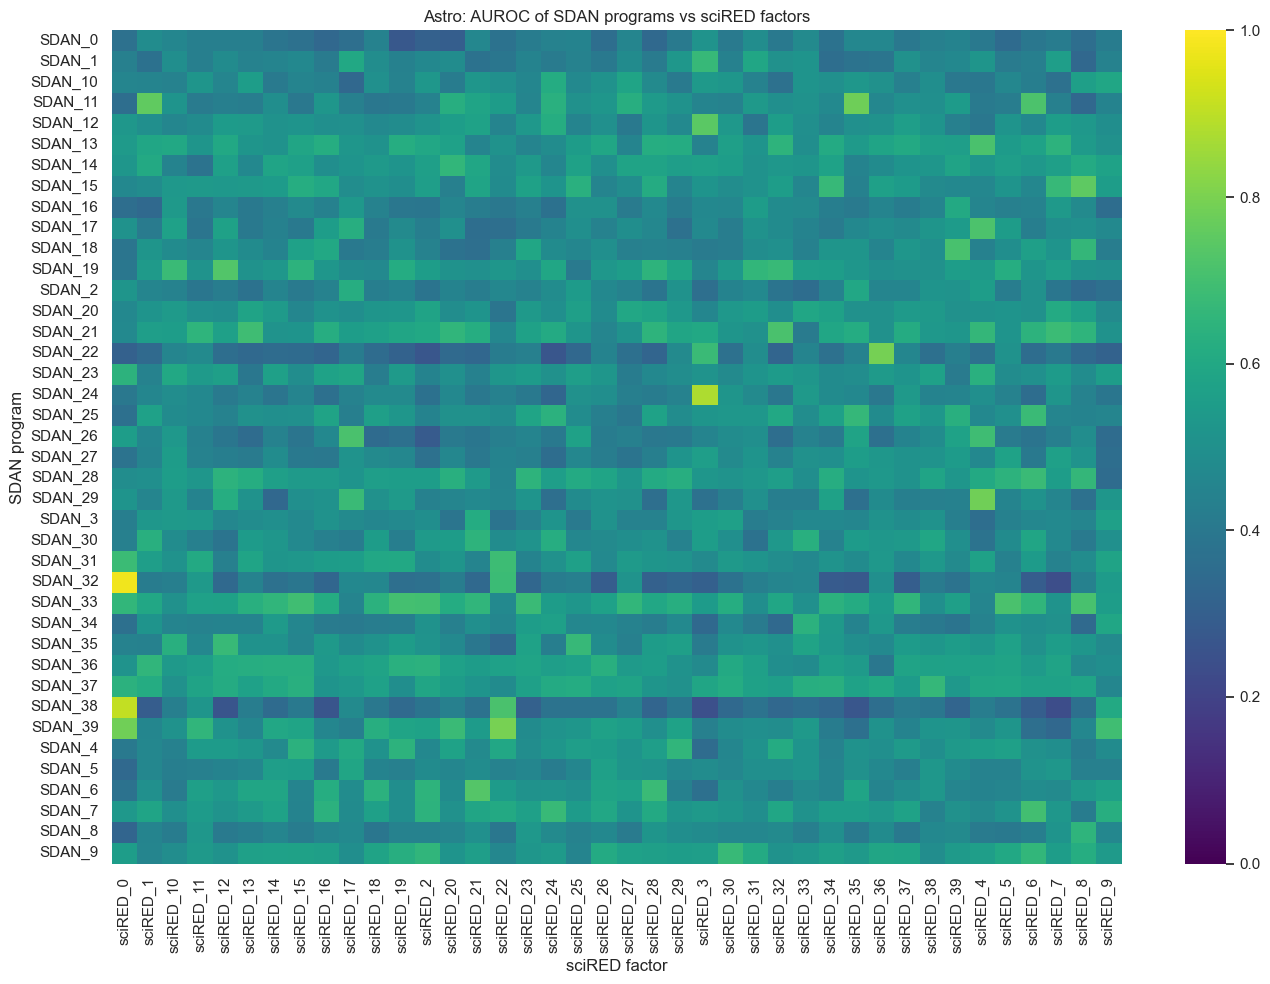

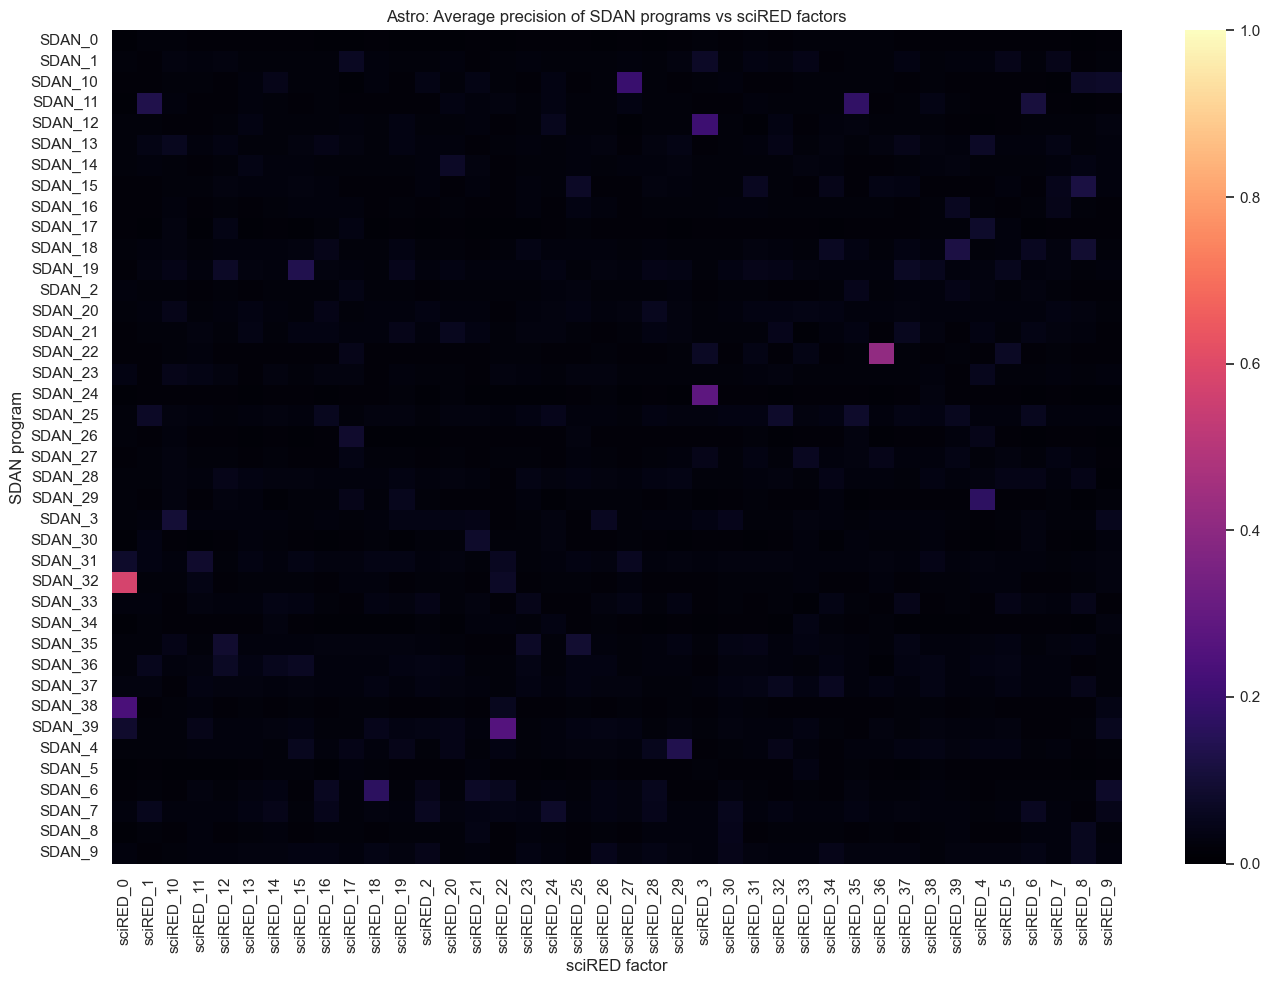

Saved CSV outputs to:
/Users/zxlin/Documents/GitHub/SDAN/SDAN_Comparison/SEA_AD/output_comparison/SDAN_vs_sciRED_loading


In [4]:
CELL_TYPE = "Astro"
SDAN_WEIGHT = "2.0"

result = compute_program_factor_metrics(CELL_TYPE, SDAN_WEIGHT)

print(f"Cell type: {CELL_TYPE}")
print(f"SDAN weight: {SDAN_WEIGHT}")
print(f"Genes in SDAN universe: {result['program_summary']['n_genes_overlap'].iloc[0]} overlapping with sciRED loadings")
display(result["program_summary"].head())

best_auroc = summarize_best_matches(result["metrics"], "auroc")
best_ap = summarize_best_matches(result["metrics"], "average_precision")

display(best_auroc.head(10))
display(best_ap.head(10))

plot_metric_heatmap(result["auroc"], f"{CELL_TYPE}: AUROC of SDAN programs vs sciRED factors")
plot_metric_heatmap(result["average_precision"], f"{CELL_TYPE}: Average precision of SDAN programs vs sciRED factors", cmap="magma")

result["metrics"].to_csv(RESULTS_DIR / f"{CELL_TYPE}_SDAN_{SDAN_WEIGHT}_vs_sciRED_program_factor_metrics.csv", index=False)
result["auroc"].to_csv(RESULTS_DIR / f"{CELL_TYPE}_SDAN_{SDAN_WEIGHT}_vs_sciRED_auroc_matrix.csv")
result["average_precision"].to_csv(RESULTS_DIR / f"{CELL_TYPE}_SDAN_{SDAN_WEIGHT}_vs_sciRED_average_precision_matrix.csv")

print("Saved CSV outputs to:")
print(RESULTS_DIR)


In [5]:
# Optional: run both SEA-AD cell types at the same SDAN graph weight.

DEFAULT_WEIGHT = "2.0"
combined_best = []

for cell_type in ["Astro", "Micro-PVM"]:
    out = compute_program_factor_metrics(cell_type, DEFAULT_WEIGHT)
    best = summarize_best_matches(out["metrics"], "average_precision")
    combined_best.append(best)

combined_best = pd.concat(combined_best, ignore_index=True)
combined_best = combined_best.sort_values(["cell_type", "average_precision"], ascending=[True, False])
display(combined_best.groupby("cell_type").head(10))

combined_best.to_csv(RESULTS_DIR / f"SEA_AD_weight_{DEFAULT_WEIGHT}_best_matches_by_average_precision.csv", index=False)


,cell_type,sdan_weight,program,factor,n_genes_overlap,n_program_genes_total,n_program_genes_overlap,auroc,average_precision
0,Astro,2.0,SDAN_32,sciRED_0,1636,45,44,0.980442,0.577646
1,Astro,2.0,SDAN_22,sciRED_36,1636,45,41,0.790259,0.412666
2,Astro,2.0,SDAN_24,sciRED_3,1636,42,29,0.875308,0.282880
3,Astro,2.0,SDAN_39,sciRED_22,1636,43,39,0.795899,0.259955
4,Astro,2.0,SDAN_38,sciRED_0,1636,45,42,0.906659,0.234481
5,Astro,2.0,SDAN_12,sciRED_3,1636,42,31,0.743101,0.204236
6,Astro,2.0,SDAN_10,sciRED_27,1636,41,34,0.585904,0.198845
7,Astro,2.0,SDAN_11,sciRED_35,1636,45,35,0.780940,0.178326
8,Astro,2.0,SDAN_29,sciRED_4,1636,43,33,0.784514,0.168986
9,Astro,2.0,SDAN_6,sciRED_18,1636,42,36,0.639201,0.164213


## Compare SDAN gene programs against Spectra loadings

This section performs the same loading-vector comparison for Spectra.

Important note:
- Spectra does **not** use the same gene list as SDAN.
- For SEA-AD, Spectra is trained on the union gene list in `gene_list_Astro_Micro-PVM_union_filtered.txt`.
- Therefore, SDAN-vs-Spectra comparisons are computed only on the overlap between the SDAN gene universe and the Spectra union gene universe.
- Genes outside that overlap are excluded from both positives and negatives for this comparison.


In [6]:
SPECTRA_OUTPUT = REPO_ROOT / "SDAN_Comparison" / "SEA_AD" / "output_comparison" / "Spectra"
SPECTRA_RESULTS_DIR = REPO_ROOT / "SDAN_Comparison" / "SEA_AD" / "output_comparison" / "SDAN_vs_Spectra_loading"
SPECTRA_RESULTS_DIR.mkdir(parents=True, exist_ok=True)


def load_sdan_spectra_inputs(cell_type: str, sdan_weight: str = "2.0"):
    sdan_gene_list_path = SDAN_OUTPUT / f"gene_list_{cell_type}_{sdan_weight}.txt"
    sdan_program_path = SDAN_OUTPUT / f"name_s_{cell_type}_{sdan_weight}.txt"
    spectra_gene_list_path = SPECTRA_OUTPUT / "gene_list_Astro_Micro-PVM_union_filtered.txt"
    spectra_loading_path = SPECTRA_OUTPUT / "train_s_Astro_Micro-PVM_union.npy"

    sdan_gene_universe = pd.read_csv(sdan_gene_list_path, header=None).iloc[:, 0].astype(str).tolist()
    sdan_program_gene_sets = read_program_gene_sets(sdan_program_path)

    spectra_genes = pd.read_csv(spectra_gene_list_path, header=None).iloc[:, 0].astype(str).tolist()
    spectra_loading = np.load(spectra_loading_path)
    spectra_factor_cols = [f"Spectra_{idx}" for idx in range(spectra_loading.shape[1])]
    spectra = pd.DataFrame(spectra_loading, index=spectra_genes, columns=spectra_factor_cols).reset_index()
    spectra = spectra.rename(columns={"index": "gene"})

    return sdan_gene_universe, sdan_program_gene_sets, spectra, spectra_factor_cols, spectra_genes


def compute_program_spectra_metrics(cell_type: str, sdan_weight: str = "2.0"):
    sdan_gene_universe, program_gene_sets, spectra, factor_cols, spectra_genes = load_sdan_spectra_inputs(cell_type, sdan_weight)
    spectra = spectra.drop_duplicates(subset="gene").set_index("gene")

    common_genes = [gene for gene in sdan_gene_universe if gene in spectra.index]
    score_matrix = spectra.loc[common_genes, factor_cols].abs()

    rows = []
    for program_name, genes_in_program in program_gene_sets.items():
        y_true = np.array([gene in genes_in_program for gene in common_genes], dtype=int)
        positive_genes = int(y_true.sum())
        negative_genes = int((1 - y_true).sum())

        if positive_genes == 0 or negative_genes == 0:
            continue

        for factor_name in factor_cols:
            y_score = score_matrix[factor_name].to_numpy()
            rows.append(
                {
                    "cell_type": cell_type,
                    "sdan_weight": sdan_weight,
                    "program": program_name,
                    "factor": factor_name,
                    "n_sdan_genes": len(sdan_gene_universe),
                    "n_spectra_genes": len(spectra_genes),
                    "n_genes_overlap": len(common_genes),
                    "n_program_genes_total": len(genes_in_program),
                    "n_program_genes_overlap": positive_genes,
                    "auroc": roc_auc_score(y_true, y_score),
                    "average_precision": average_precision_score(y_true, y_score),
                }
            )

    metrics = pd.DataFrame(rows)
    auroc_mat = metrics.pivot(index="program", columns="factor", values="auroc")
    ap_mat = metrics.pivot(index="program", columns="factor", values="average_precision")
    program_summary = (
        metrics[["program", "n_sdan_genes", "n_spectra_genes", "n_genes_overlap", "n_program_genes_total", "n_program_genes_overlap"]]
        .drop_duplicates()
        .sort_values("program")
        .reset_index(drop=True)
    )

    return {
        "common_genes": common_genes,
        "metrics": metrics,
        "auroc": auroc_mat,
        "average_precision": ap_mat,
        "program_summary": program_summary,
    }


Cell type: Astro
SDAN weight: 2.0
SDAN genes: 2000, Spectra genes: 2847, overlap used for metrics: 1481


,program,n_sdan_genes,n_spectra_genes,n_genes_overlap,n_program_genes_total,n_program_genes_overlap
0,SDAN_0,2000,2847,1481,43,36
1,SDAN_1,2000,2847,1481,45,29
2,SDAN_10,2000,2847,1481,41,36
3,SDAN_11,2000,2847,1481,45,27
4,SDAN_12,2000,2847,1481,42,37


,cell_type,sdan_weight,program,factor,n_sdan_genes,n_spectra_genes,n_genes_overlap,n_program_genes_total,n_program_genes_overlap,auroc,average_precision
0,Astro,2.0,SDAN_32,Spectra_28,2000,2847,1481,45,22,0.975512,0.460291
1,Astro,2.0,SDAN_17,Spectra_21,2000,2847,1481,44,21,0.932355,0.186898
2,Astro,2.0,SDAN_24,Spectra_16,2000,2847,1481,42,38,0.893442,0.301099
3,Astro,2.0,SDAN_22,Spectra_11,2000,2847,1481,45,22,0.873076,0.204380
4,Astro,2.0,SDAN_38,Spectra_12,2000,2847,1481,45,17,0.855914,0.238415
5,Astro,2.0,SDAN_39,Spectra_28,2000,2847,1481,43,25,0.841319,0.116162
6,Astro,2.0,SDAN_33,Spectra_29,2000,2847,1481,42,31,0.835528,0.092072
7,Astro,2.0,SDAN_4,Spectra_21,2000,2847,1481,44,20,0.825838,0.063226
8,Astro,2.0,SDAN_2,Spectra_21,2000,2847,1481,45,26,0.825112,0.053674
9,Astro,2.0,SDAN_26,Spectra_21,2000,2847,1481,45,25,0.821126,0.100416


,cell_type,sdan_weight,program,factor,n_sdan_genes,n_spectra_genes,n_genes_overlap,n_program_genes_total,n_program_genes_overlap,auroc,average_precision
0,Astro,2.0,SDAN_32,Spectra_28,2000,2847,1481,45,22,0.975512,0.460291
1,Astro,2.0,SDAN_10,Spectra_17,2000,2847,1481,41,36,0.779354,0.307998
2,Astro,2.0,SDAN_24,Spectra_16,2000,2847,1481,42,38,0.893442,0.301099
3,Astro,2.0,SDAN_38,Spectra_12,2000,2847,1481,45,17,0.855914,0.238415
4,Astro,2.0,SDAN_22,Spectra_11,2000,2847,1481,45,22,0.873076,0.204380
5,Astro,2.0,SDAN_17,Spectra_21,2000,2847,1481,44,21,0.932355,0.186898
6,Astro,2.0,SDAN_12,Spectra_16,2000,2847,1481,42,37,0.803493,0.186424
7,Astro,2.0,SDAN_33,Spectra_15,2000,2847,1481,42,31,0.827875,0.147665
8,Astro,2.0,SDAN_4,Spectra_27,2000,2847,1481,44,20,0.756605,0.146950
9,Astro,2.0,SDAN_29,Spectra_21,2000,2847,1481,43,33,0.792839,0.140758


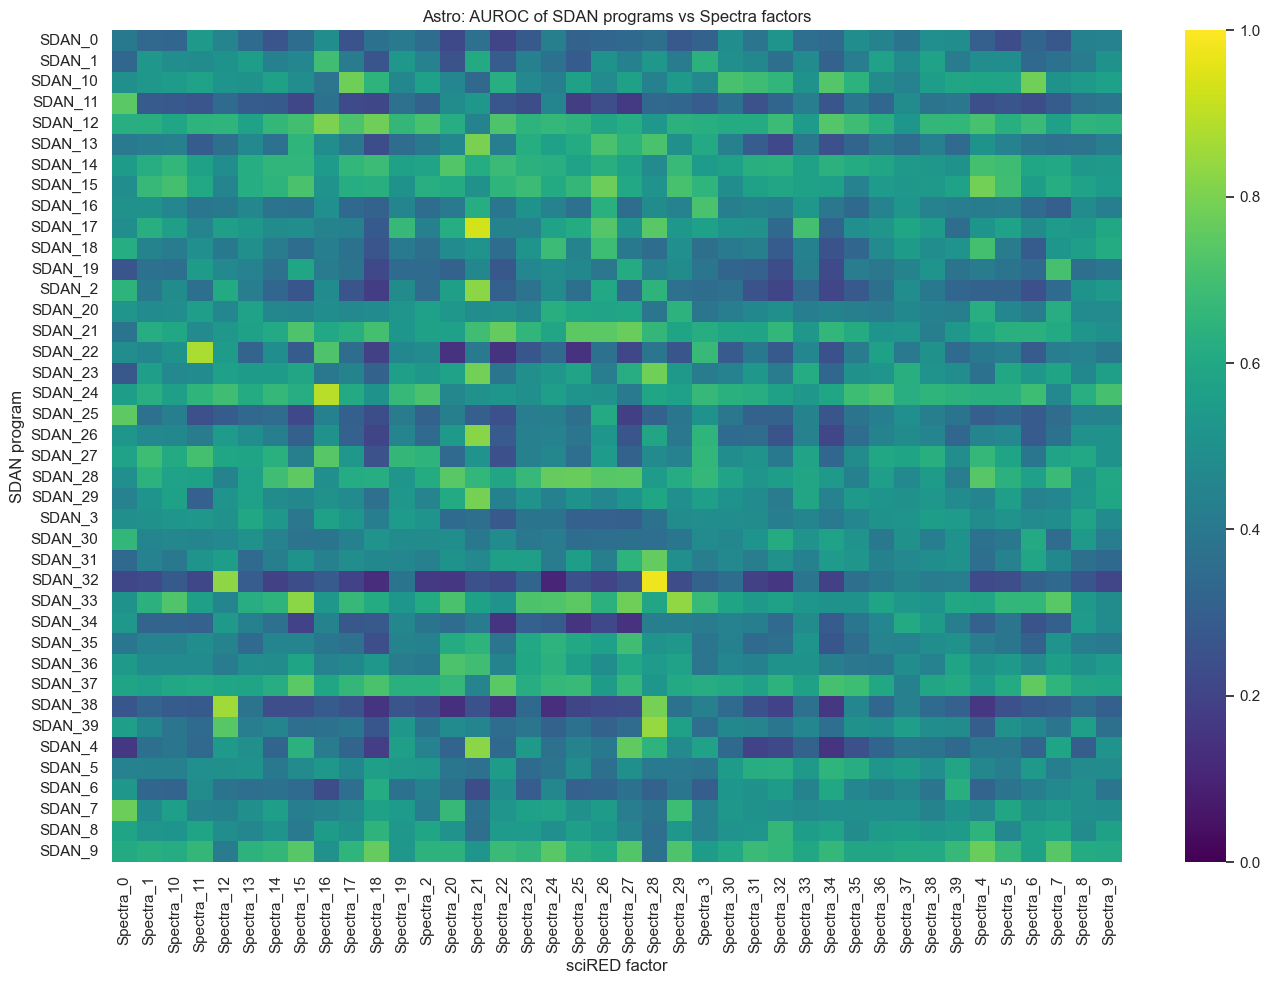

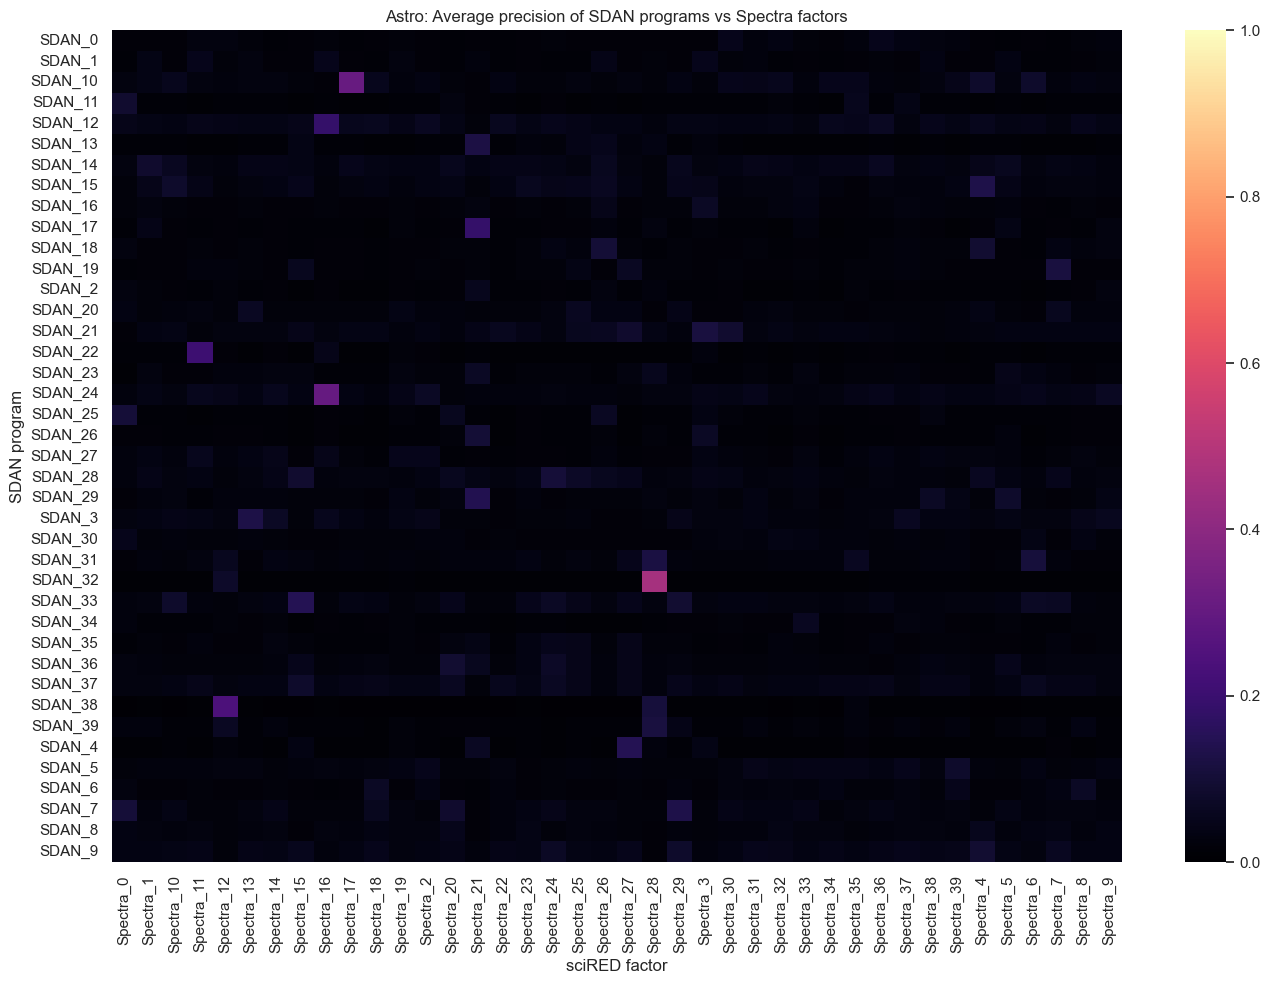

Saved Spectra comparison CSV outputs to:
/Users/zxlin/Documents/GitHub/SDAN/SDAN_Comparison/SEA_AD/output_comparison/SDAN_vs_Spectra_loading


In [7]:
SPECTRA_CELL_TYPE = "Astro"
SPECTRA_SDAN_WEIGHT = "2.0"

spectra_result = compute_program_spectra_metrics(SPECTRA_CELL_TYPE, SPECTRA_SDAN_WEIGHT)

print(f"Cell type: {SPECTRA_CELL_TYPE}")
print(f"SDAN weight: {SPECTRA_SDAN_WEIGHT}")
print(
    f"SDAN genes: {spectra_result['program_summary']['n_sdan_genes'].iloc[0]}, "
    f"Spectra genes: {spectra_result['program_summary']['n_spectra_genes'].iloc[0]}, "
    f"overlap used for metrics: {spectra_result['program_summary']['n_genes_overlap'].iloc[0]}"
)
display(spectra_result["program_summary"].head())

spectra_best_auroc = summarize_best_matches(spectra_result["metrics"], "auroc")
spectra_best_ap = summarize_best_matches(spectra_result["metrics"], "average_precision")

display(spectra_best_auroc.head(10))
display(spectra_best_ap.head(10))

plot_metric_heatmap(spectra_result["auroc"], f"{SPECTRA_CELL_TYPE}: AUROC of SDAN programs vs Spectra factors")
plot_metric_heatmap(spectra_result["average_precision"], f"{SPECTRA_CELL_TYPE}: Average precision of SDAN programs vs Spectra factors", cmap="magma")

spectra_result["metrics"].to_csv(SPECTRA_RESULTS_DIR / f"{SPECTRA_CELL_TYPE}_SDAN_{SPECTRA_SDAN_WEIGHT}_vs_Spectra_program_factor_metrics.csv", index=False)
spectra_result["auroc"].to_csv(SPECTRA_RESULTS_DIR / f"{SPECTRA_CELL_TYPE}_SDAN_{SPECTRA_SDAN_WEIGHT}_vs_Spectra_auroc_matrix.csv")
spectra_result["average_precision"].to_csv(SPECTRA_RESULTS_DIR / f"{SPECTRA_CELL_TYPE}_SDAN_{SPECTRA_SDAN_WEIGHT}_vs_Spectra_average_precision_matrix.csv")

print("Saved Spectra comparison CSV outputs to:")
print(SPECTRA_RESULTS_DIR)


In [8]:
# Optional: run both SEA-AD cell types for SDAN vs Spectra at the same SDAN graph weight.

SPECTRA_DEFAULT_WEIGHT = "2.0"
combined_spectra_best = []

for cell_type in ["Astro", "Micro-PVM"]:
    out = compute_program_spectra_metrics(cell_type, SPECTRA_DEFAULT_WEIGHT)
    best = summarize_best_matches(out["metrics"], "average_precision")
    combined_spectra_best.append(best)

combined_spectra_best = pd.concat(combined_spectra_best, ignore_index=True)
combined_spectra_best = combined_spectra_best.sort_values(["cell_type", "average_precision"], ascending=[True, False])
display(combined_spectra_best.groupby("cell_type").head(10))

combined_spectra_best.to_csv(SPECTRA_RESULTS_DIR / f"SEA_AD_weight_{SPECTRA_DEFAULT_WEIGHT}_best_Spectra_matches_by_average_precision.csv", index=False)


,cell_type,sdan_weight,program,factor,n_sdan_genes,n_spectra_genes,n_genes_overlap,n_program_genes_total,n_program_genes_overlap,auroc,average_precision
0,Astro,2.0,SDAN_32,Spectra_28,2000,2847,1481,45,22,0.975512,0.460291
1,Astro,2.0,SDAN_10,Spectra_17,2000,2847,1481,41,36,0.779354,0.307998
2,Astro,2.0,SDAN_24,Spectra_16,2000,2847,1481,42,38,0.893442,0.301099
3,Astro,2.0,SDAN_38,Spectra_12,2000,2847,1481,45,17,0.855914,0.238415
4,Astro,2.0,SDAN_22,Spectra_11,2000,2847,1481,45,22,0.873076,0.204380
5,Astro,2.0,SDAN_17,Spectra_21,2000,2847,1481,44,21,0.932355,0.186898
6,Astro,2.0,SDAN_12,Spectra_16,2000,2847,1481,42,37,0.803493,0.186424
7,Astro,2.0,SDAN_33,Spectra_15,2000,2847,1481,42,31,0.827875,0.147665
8,Astro,2.0,SDAN_4,Spectra_27,2000,2847,1481,44,20,0.756605,0.146950
9,Astro,2.0,SDAN_29,Spectra_21,2000,2847,1481,43,33,0.792839,0.140758


## SDAN connectivity quantile vs comparison score

For each SDAN program, we can reproduce the graph-connectivity quantile used in `check_weight.py`.

Procedure:
- use SDAN genes with loading `> 0.8` for that program,
- compute within-program average degree in the SDAN gene graph,
- compare that degree to random gene sets of the same size,
- define the connectivity quantile as the fraction of random sets with lower degree.

The scatterplots below place one point per SDAN program:
- x-axis: best AUROC or best average precision against another method,
- y-axis: SDAN connectivity quantile.


,cell_type,sdan_weight,program,n_active_genes,n_internal_edges,avg_degree,connectivity_quantile
0,Astro,2.0,SDAN_0,43,0,0.000000,0.0
1,Astro,2.0,SDAN_1,45,0,0.000000,0.0
2,Astro,2.0,SDAN_10,41,100,4.878049,1.0
3,Astro,2.0,SDAN_11,45,0,0.000000,0.0
4,Astro,2.0,SDAN_12,42,112,5.333333,1.0


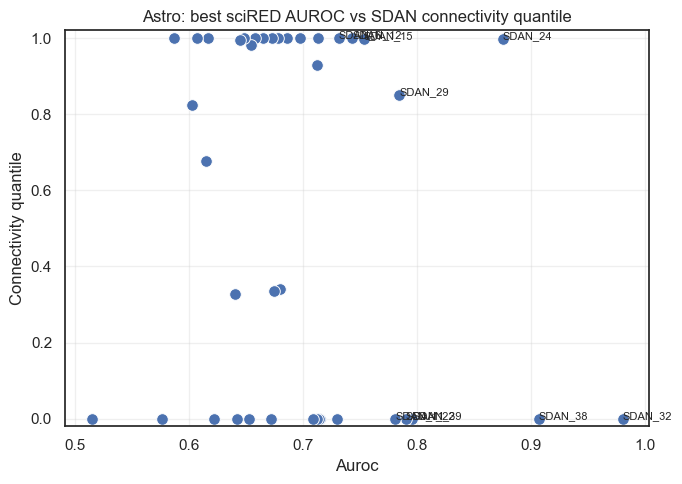

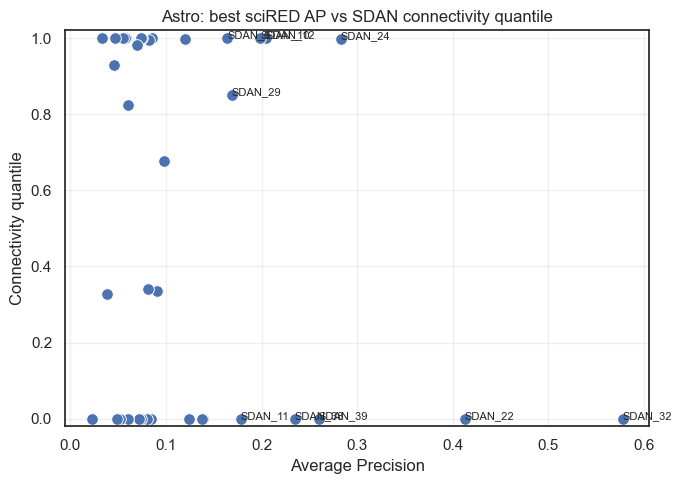

,cell_type,sdan_weight,program,n_active_genes,n_internal_edges,avg_degree,connectivity_quantile
0,Micro-PVM,2.0,SDAN_0,39,0,0.000000,0.000
1,Micro-PVM,2.0,SDAN_1,37,158,8.540541,1.000
2,Micro-PVM,2.0,SDAN_10,37,24,1.297297,1.000
3,Micro-PVM,2.0,SDAN_11,39,18,0.923077,0.996
4,Micro-PVM,2.0,SDAN_12,39,24,1.230769,1.000


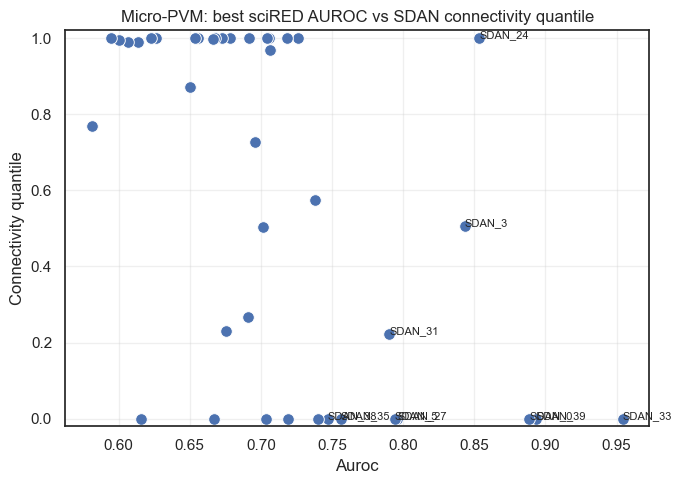

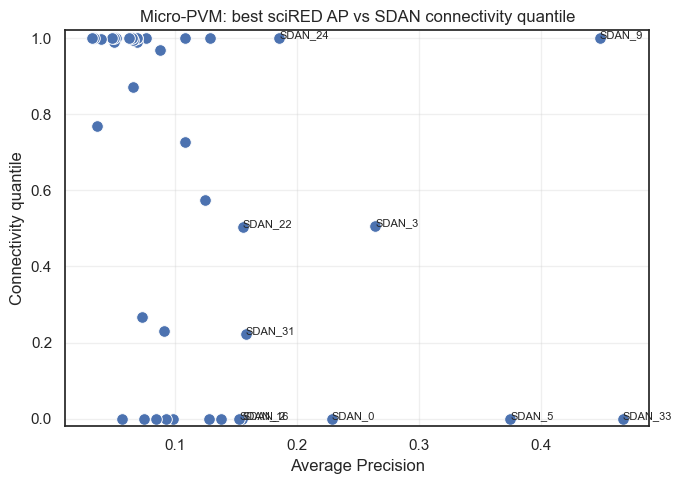

In [9]:
# SDAN vs sciRED: one scatterplot per cell type.

CONNECTIVITY_WEIGHT = "2.0"
CONNECTIVITY_THRESHOLD = 0.8

for cell_type in ["Astro", "Micro-PVM"]:
    metrics = compute_program_factor_metrics(cell_type, CONNECTIVITY_WEIGHT)["metrics"]
    connectivity = compute_sdan_connectivity_quantiles(
        cell_type,
        CONNECTIVITY_WEIGHT,
        threshold=CONNECTIVITY_THRESHOLD,
    )

    display(connectivity.head())

    plot_program_score_vs_connectivity(
        metrics,
        connectivity,
        score_col="auroc",
        title=f"{cell_type}: best sciRED AUROC vs SDAN connectivity quantile",
    )
    plot_program_score_vs_connectivity(
        metrics,
        connectivity,
        score_col="average_precision",
        title=f"{cell_type}: best sciRED AP vs SDAN connectivity quantile",
    )


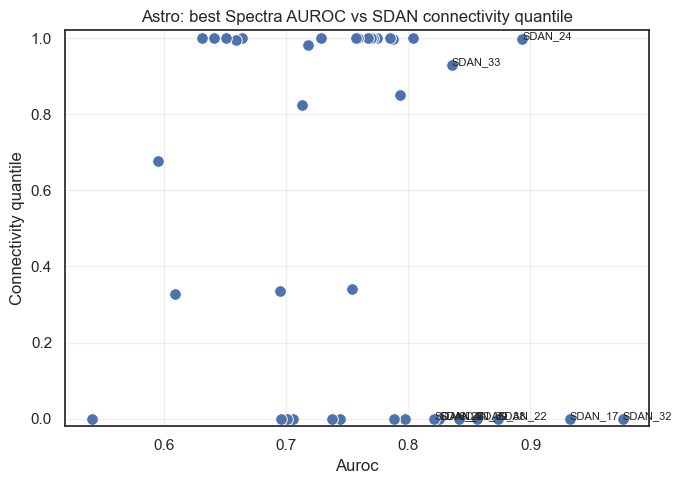

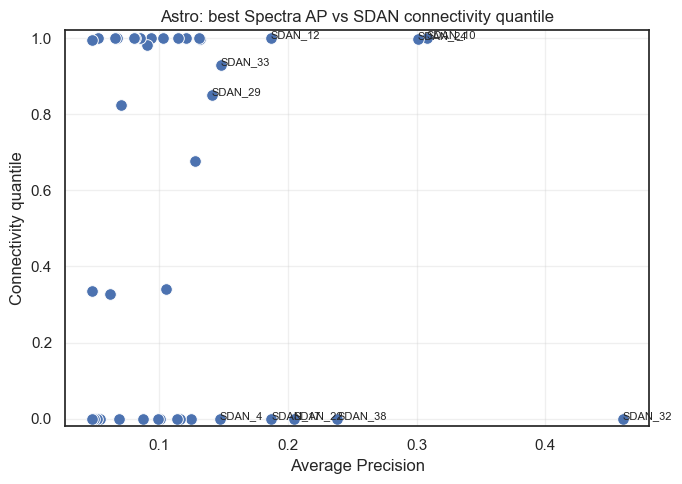

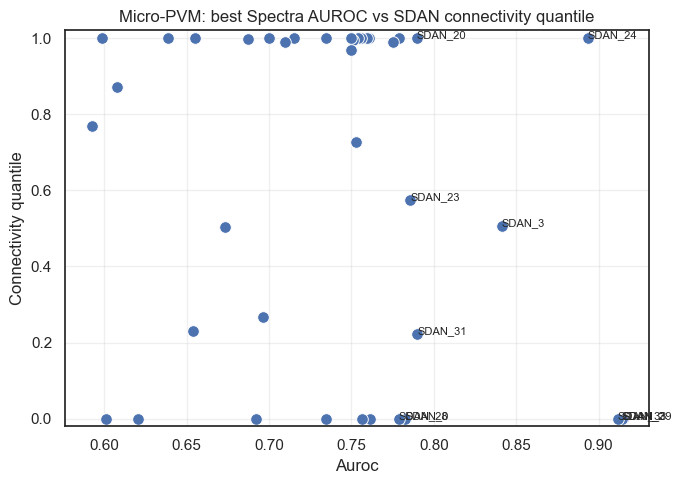

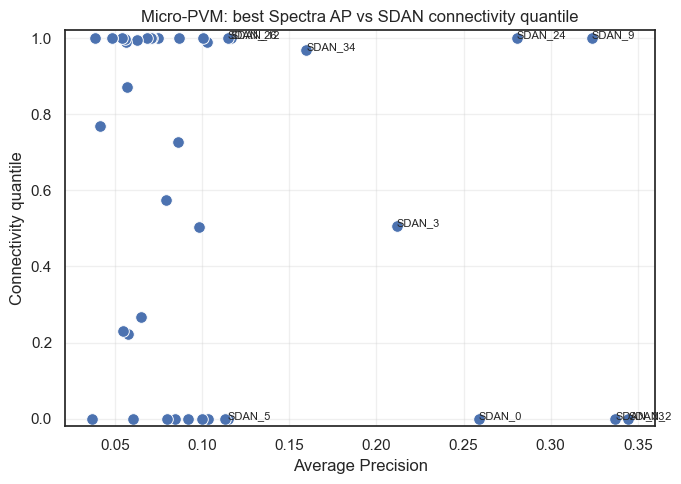

In [10]:
# SDAN vs Spectra: one scatterplot per cell type.

for cell_type in ["Astro", "Micro-PVM"]:
    metrics = compute_program_spectra_metrics(cell_type, CONNECTIVITY_WEIGHT)["metrics"]
    connectivity = compute_sdan_connectivity_quantiles(
        cell_type,
        CONNECTIVITY_WEIGHT,
        threshold=CONNECTIVITY_THRESHOLD,
    )

    plot_program_score_vs_connectivity(
        metrics,
        connectivity,
        score_col="auroc",
        title=f"{cell_type}: best Spectra AUROC vs SDAN connectivity quantile",
    )
    plot_program_score_vs_connectivity(
        metrics,
        connectivity,
        score_col="average_precision",
        title=f"{cell_type}: best Spectra AP vs SDAN connectivity quantile",
    )
